In [2]:
import os
os.getcwd()

'C:\\Users\\Fia Thottan\\SensingProject'

In [3]:
import torch
import torchvision
import os
import pandas as pd
from PIL import Image
from pathlib import Path
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import torch.nn as nn
import torch.optim as optim
from copy import deepcopy
import numpy as np
from sklearn.metrics import f1_score
import json
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import torch.nn.functional as F

In [4]:
import sys
print(sys.executable)

C:\Users\Public\anaconda3\python.exe


In [9]:
import sys
!{sys.executable} -m pip install torch torchvision torchaudio


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import torch
import torchvision

print("Torch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)


Torch version: 2.10.0+cpu
Torchvision version: 0.25.0+cpu


In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [7]:
## Loading RGB Data

In [8]:
def load_rgb_metadata(csv_path: str) -> pd.DataFrame:
    """
    Load the posture CSV and keep only RGB rows.
    """
    df = pd.read_csv(csv_path)
    df_rgb = df[df["modality"] == "RGB"].copy()
    df_rgb.reset_index(drop=True, inplace=True)
    return df_rgb

In [9]:
def load_rgb_image(dataset_root: str, relative_image_path: str) -> Image.Image:
    """
    Load an RGB image from its relative path in the CSV.
    """

    full_path = os.path.join(dataset_root, relative_image_path)

    if not os.path.exists(full_path):
        raise FileNotFoundError(f"Image not found: {full_path}")

    image = Image.open(full_path).convert("RGB")  # RGB image (3 channels)
    return image

In [10]:
def get_rgb_sample(df_rgb: pd.DataFrame, idx: int, dataset_root: str):

    row = df_rgb.iloc[idx]

    image = load_rgb_image(dataset_root, row["image_path"])
    label = int(row["label_id"])

    sample = {
        "image": image,
        "label": label,
        "label_name": row["label"],
        "subject_id": row["subject_id"],
        "condition": row["condition"],
        "image_index": row["image_index"],
        "image_path": row["image_path"]
    }

    return sample

In [11]:
dataset_root = Path("SLP2022/SLP/danaLab")
csv_path = Path("SLP2022/SLP/danaLab/posture_labels_all_modalities.csv")

df_rgb = load_rgb_metadata(csv_path)

print(df_rgb.shape)
df_rgb.head()

(13770, 8)


,subject_id,modality,condition,image_index,image_path,label,label_id,source
0,1,RGB,uncover,1,00001/RGB/uncover/image_000001.png,supine,0,inferred_ordering
1,1,RGB,uncover,2,00001/RGB/uncover/image_000002.png,supine,0,inferred_ordering
2,1,RGB,uncover,3,00001/RGB/uncover/image_000003.png,supine,0,inferred_ordering
3,1,RGB,uncover,4,00001/RGB/uncover/image_000004.png,supine,0,inferred_ordering
4,1,RGB,uncover,5,00001/RGB/uncover/image_000005.png,supine,0,inferred_ordering


Label ID: 0
Label Name: supine
Subject ID: 1
Condition: uncover


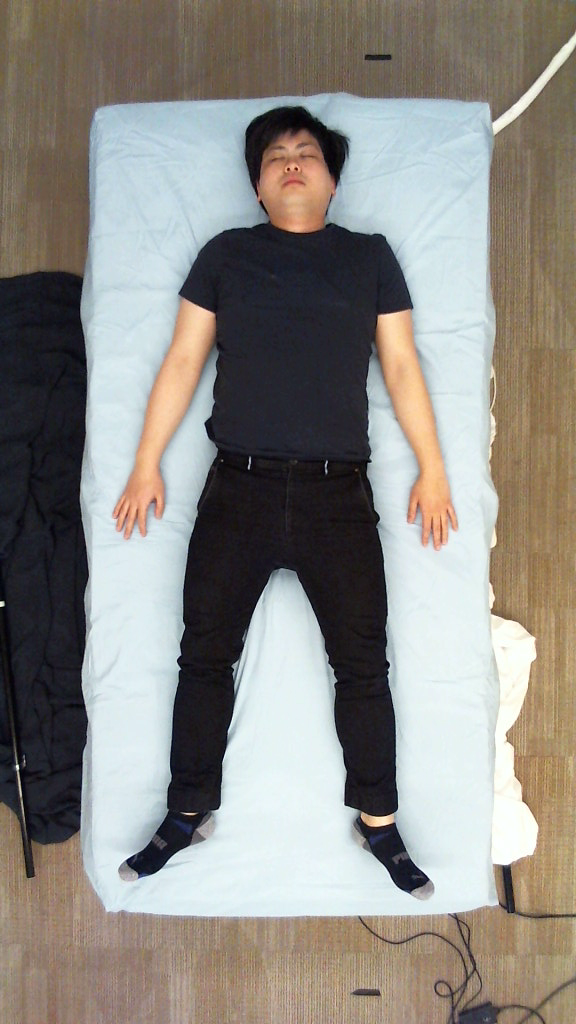

In [12]:
sample = get_rgb_sample(df_rgb, idx=0, dataset_root=dataset_root)

print("Label ID:", sample["label"])
print("Label Name:", sample["label_name"])
print("Subject ID:", sample["subject_id"])
print("Condition:", sample["condition"])

sample["image"]

In [13]:
## Train Validation and Test Split

In [14]:
def create_subjectwise_splits(
    df,
    subject_col="subject_id",
    train_size=0.70,
    val_size=0.15,
    test_size=0.15,
    random_state=42,
):
    """
    Create subject-wise train/val/test splits.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe (e.g., filtered RGB dataframe).
    subject_col : str
        Column containing subject IDs.
    train_size : float
        Fraction of subjects for training.
    val_size : float
        Fraction of subjects for validation.
    test_size : float
        Fraction of subjects for testing.
    random_state : int
        Seed for reproducibility.

    Returns
    -------
    train_df, val_df, test_df, train_subjects, val_subjects, test_subjects
    """
    total = train_size + val_size + test_size
    if abs(total - 1.0) > 1e-8:
        raise ValueError("train_size + val_size + test_size must sum to 1.0")

    subjects = sorted(df[subject_col].astype(str).unique())

    # first split: train vs temp
    train_subjects, temp_subjects = train_test_split(
        subjects,
        train_size=train_size,
        random_state=random_state,
        shuffle=True
    )

    # second split: val vs test from temp
    relative_val_size = val_size / (val_size + test_size)

    val_subjects, test_subjects = train_test_split(
        temp_subjects,
        train_size=relative_val_size,
        random_state=random_state,
        shuffle=True
    )

    # filter rows based on subject split
    train_df = df[df[subject_col].astype(str).isin(train_subjects)].copy()
    val_df = df[df[subject_col].astype(str).isin(val_subjects)].copy()
    test_df = df[df[subject_col].astype(str).isin(test_subjects)].copy()

    return train_df, val_df, test_df, train_subjects, val_subjects, test_subjects

In [15]:
train_df, val_df, test_df, train_subjects, val_subjects, test_subjects = create_subjectwise_splits(
    df_rgb,
    subject_col="subject_id",
    train_size=0.70,
    val_size=0.15,
    test_size=0.15,
    random_state=42
)

In [16]:
print("Number of train subjects:", len(train_subjects))
print("Number of val subjects:", len(val_subjects))
print("Number of test subjects:", len(test_subjects))

print("Train samples:", len(train_df))
print("Val samples:", len(val_df))
print("Test samples:", len(test_df))

Number of train subjects: 71
Number of val subjects: 15
Number of test subjects: 16
Train samples: 9585
Val samples: 2025
Test samples: 2160


In [17]:
print("Train labels:\n", train_df["label"].value_counts())
print("\nVal labels:\n", val_df["label"].value_counts())
print("\nTest labels:\n", test_df["label"].value_counts())

Train labels:
 label
supine    3195
left      3195
right     3195
Name: count, dtype: int64

Val labels:
 label
supine    675
left      675
right     675
Name: count, dtype: int64

Test labels:
 label
supine    720
left      720
right     720
Name: count, dtype: int64


In [18]:
#check subject overlap
print("Train-Val overlap:", set(train_subjects).intersection(set(val_subjects)))
print("Train-Test overlap:", set(train_subjects).intersection(set(test_subjects)))
print("Val-Test overlap:", set(val_subjects).intersection(set(test_subjects)))

Train-Val overlap: set()
Train-Test overlap: set()
Val-Test overlap: set()


In [19]:
df_rgb["split"] = "unassigned"
df_rgb.loc[df_rgb["subject_id"].astype(str).isin(train_subjects), "split"] = "train"
df_rgb.loc[df_rgb["subject_id"].astype(str).isin(val_subjects), "split"] = "val"
df_rgb.loc[df_rgb["subject_id"].astype(str).isin(test_subjects), "split"] = "test"

df_rgb["split"].value_counts()

split
train    9585
test     2160
val      2025
Name: count, dtype: int64

In [20]:
print(train_df.head)

<bound method NDFrame.head of        subject_id modality condition  image_index  \
135             2      RGB   uncover            1   
136             2      RGB   uncover            2   
137             2      RGB   uncover            3   
138             2      RGB   uncover            4   
139             2      RGB   uncover            5   
...           ...      ...       ...          ...   
13630         101      RGB    cover2           41   
13631         101      RGB    cover2           42   
13632         101      RGB    cover2           43   
13633         101      RGB    cover2           44   
13634         101      RGB    cover2           45   

                               image_path   label  label_id             source  
135    00002/RGB/uncover/image_000001.png  supine         0  inferred_ordering  
136    00002/RGB/uncover/image_000002.png  supine         0  inferred_ordering  
137    00002/RGB/uncover/image_000003.png  supine         0  inferred_ordering  
138    00

In [21]:
## RGB Dataset and DataLoader

In [22]:
# Define image preprocessing and normalization transforms for training and evaluation
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [23]:
# Custom PyTorch Dataset for loading RGB images and associated posture labels from the metadata dataframe
class RGBDataset(Dataset):
    def __init__(self, dataframe, dataset_root, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.dataset_root = dataset_root
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]

        image = load_rgb_image(self.dataset_root, row["image_path"])
        label = int(row["label_id"])

        if self.transform is not None:
            image = self.transform(image)

        sample = {
            "image": image,
            "label": torch.tensor(label, dtype=torch.long),
            "label_name": row["label"],
            "subject_id": str(row["subject_id"]),
            "condition": row["condition"],
            "image_index": row["image_index"],
            "image_path": row["image_path"],
        }

        return sample

In [24]:
# Create dataset instances for train, validation, and test splits
train_dataset = RGBDataset(
    dataframe=train_df,
    dataset_root=dataset_root,
    transform=train_transform
)

val_dataset = RGBDataset(
    dataframe=val_df,
    dataset_root=dataset_root,
    transform=eval_transform
)

test_dataset = RGBDataset(
    dataframe=test_df,
    dataset_root=dataset_root,
    transform=eval_transform
)

In [25]:
print("Train dataset size:", len(train_dataset))
print("Validation dataset size:", len(val_dataset))
print("Test dataset size:", len(test_dataset))

Train dataset size: 9585
Validation dataset size: 2025
Test dataset size: 2160


In [26]:
#test to check resized correctly for resnet
sample = train_dataset[0]

print("Image tensor shape:", sample["image"].shape)
print("Label:", sample["label"])
print("Label name:", sample["label_name"])
print("Subject ID:", sample["subject_id"])
print("Condition:", sample["condition"])

Image tensor shape: torch.Size([3, 224, 224])
Label: tensor(0)
Label name: supine
Subject ID: 2
Condition: uncover


In [27]:
# Wrap datasets with DataLoaders to enable batch loading during model training and evaluation
batch_size = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

In [28]:
#verification check
batch = next(iter(train_loader))

print("Batch image shape:", batch["image"].shape)
print("Batch label shape:", batch["label"].shape)
print("First 5 labels:", batch["label"][:5])
print("First 5 conditions:", batch["condition"][:5])

Batch image shape: torch.Size([16, 3, 224, 224])
Batch label shape: torch.Size([16])
First 5 labels: tensor([0, 1, 2, 2, 0])
First 5 conditions: ['cover2', 'uncover', 'uncover', 'uncover', 'uncover']


In [29]:
#visualization check
def show_tensor_image(tensor, title=None):
    img = tensor.permute(1, 2, 0).numpy()

    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    img = std * img + mean
    img = np.clip(img, 0, 1)

    plt.imshow(img)
    if title:
        plt.title(title)
    plt.axis("off")
    plt.show()
    

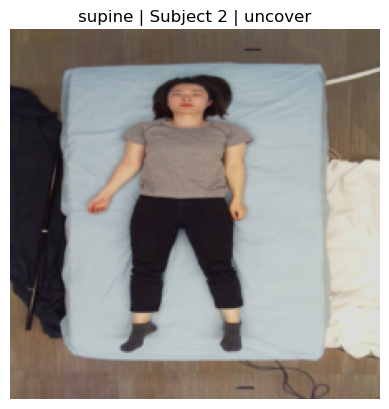

In [30]:
show_tensor_image(
    sample["image"],
    title=f'{sample["label_name"]} | Subject {sample["subject_id"]} | {sample["condition"]}'
)

In [32]:
def show_rgb_batch(dataloader, class_names, num_images=6):

    batch = next(iter(dataloader))
    images = batch["image"]
    labels = batch["label"]

    fig, axes = plt.subplots(1, num_images, figsize=(15,5))

    for i in range(num_images):

        img = images[i].permute(1,2,0).numpy()

        # undo normalization
        mean = np.array([0.485,0.456,0.406])
        std = np.array([0.229,0.224,0.225])

        img = std * img + mean
        img = np.clip(img,0,1)

        axes[i].imshow(img)
        axes[i].set_title(class_names[labels[i].item()])
        axes[i].axis("off")

    plt.show()

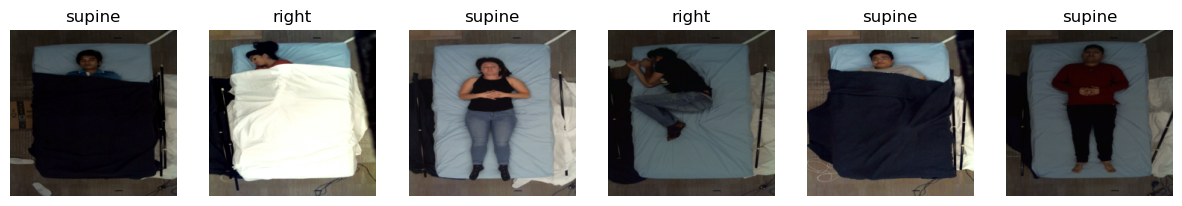

In [33]:
class_names = ["supine", "left", "right"]
show_rgb_batch(train_loader, class_names, num_images=6)

In [41]:
##Define RGB ReSNet Coder

In [40]:
# Define the RGB ResNet18 encoder and a temporary classifier head for 3-class posture classification
class RGBEncoder(nn.Module):
    def __init__(self, embedding_dim=128, pretrained=True):
        super().__init__()

        backbone = models.resnet18(
            weights=models.ResNet18_Weights.DEFAULT if pretrained else None
        )

        in_features = backbone.fc.in_features
        backbone.fc = nn.Identity()   # remove original classification head

        self.backbone = backbone
        self.projection = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, embedding_dim)
        )

    def forward(self, x):
        features = self.backbone(x)        # [B, 512]
        embedding = self.projection(features)  # [B, embedding_dim]
        return embedding
        

In [41]:
class RGBClassifier(nn.Module):
    def __init__(self, num_classes=3, embedding_dim=128, pretrained=True):
        super().__init__()
        self.feature_dim = embedding_dim
        self.encoder = RGBEncoder(embedding_dim=embedding_dim, pretrained=pretrained)
        self.classifier = nn.Linear(embedding_dim, num_classes)

    def forward(self, x):
        embedding = self.encoder(x)
        logits = self.classifier(embedding)
        return logits

In [42]:
model = RGBClassifier(num_classes=3, embedding_dim=128, pretrained=True).to(device)
print(model) 

RGBClassifier(
  (encoder): RGBEncoder(
    (backbone): ResNet(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU(inplace=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (1): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1):

In [43]:
#quick test before train
batch = next(iter(train_loader))
images = batch["image"].to(device)

outputs = model(images)

print("Input shape:", images.shape)
print("Output shape:", outputs.shape)

Input shape: torch.Size([16, 3, 224, 224])
Output shape: torch.Size([16, 3])


In [44]:
# Define the loss function and optimizer for training the RGB classifier
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

def count_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Trainable parameters:", count_trainable_parameters(model))

Trainable parameters: 11341123


In [45]:
# Compute accuracy and macro F1 for classification
def compute_classification_metrics(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    accuracy = (y_true == y_pred).mean()
    macro_f1 = f1_score(y_true, y_pred, average="macro")

    return accuracy, macro_f1

In [46]:
#Train the classifier

# Train the RGB classifier for one epoch
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    for batch in loader:
        images = batch["image"].to(device)
        labels = batch["label"].to(device)

        optimizer.zero_grad()

        logits = model(images)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc, epoch_macro_f1 = compute_classification_metrics(all_labels, all_preds)

    return epoch_loss, epoch_acc, epoch_macro_f1

In [47]:
# Evaluate the RGB classifier on validation or test data
@torch.no_grad()
def validate_one_epoch(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    for batch in loader:
        images = batch["image"].to(device)
        labels = batch["label"].to(device)

        logits = model(images)
        loss = criterion(logits, labels)

        running_loss += loss.item() * images.size(0)

        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc, epoch_macro_f1 = compute_classification_metrics(all_labels, all_preds)

    return epoch_loss, epoch_acc, epoch_macro_f1

In [48]:
# Collect predictions, labels, and probabilities for a full dataloader
@torch.no_grad()
def get_predictions_and_labels(model, loader, device):
    model.eval()

    all_labels = []
    all_preds = []
    all_probs = []

    for batch in loader:
        images = batch["image"].to(device)
        labels = batch["label"].to(device)

        logits = model(images)
        probs = F.softmax(logits, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

    return np.array(all_labels), np.array(all_preds), np.array(all_probs)

In [49]:
# Save a few example RGB predictions as a figure
def save_example_predictions(model, dataset, device, class_names, indices, save_path):
    model.eval()

    fig, axes = plt.subplots(1, len(indices), figsize=(5 * len(indices), 4))

    if len(indices) == 1:
        axes = [axes]

    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    with torch.no_grad():
        for ax, idx in zip(axes, indices):
            sample = dataset[idx]
            image = sample["image"]
            true_label = sample["label"].item()

            input_tensor = image.unsqueeze(0).to(device)

            logits = model(input_tensor)
            probs = F.softmax(logits, dim=1)
            pred_label = torch.argmax(probs, dim=1).item()
            confidence = probs[0, pred_label].item()

            image_np = image.permute(1, 2, 0).cpu().numpy()
            image_np = std * image_np + mean
            image_np = np.clip(image_np, 0, 1)

            ax.imshow(image_np)
            ax.set_title(
                f"True: {class_names[true_label]}\n"
                f"Pred: {class_names[pred_label]}\n"
                f"Conf: {confidence:.3f}"
            )
            ax.axis("off")

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Saved example predictions to: {save_path}")

In [50]:
# Save full checkpoint including model, optimizer, and metadata
def save_full_checkpoint(path, model, optimizer, epoch, best_val_acc, best_val_f1, num_classes):
    checkpoint = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "encoder_state_dict": model.encoder.state_dict(),
        "classifier_state_dict": model.classifier.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "best_val_acc": best_val_acc,
        "best_val_macro_f1": best_val_f1,
        "feature_dim": model.feature_dim,
        "num_classes": num_classes,
        "architecture": "RGBResNet18Classifier"
    }
    torch.save(checkpoint, path)
# Save only encoder weights for later multimodal fusion
def save_encoder_only(path, model):
    encoder_checkpoint = {
        "encoder_state_dict": model.encoder.state_dict(),
        "feature_dim": model.feature_dim,
        "architecture": "ResNet18_rgb_encoder"
    }
    torch.save(encoder_checkpoint, path)

In [51]:
MODEL_NAME = "rgb_resnet18_encoder"
IMAGE_SIZE = (224, 224)
BATCH_SIZE = batch_size
NUM_EPOCHS = 10
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 0.0
NUM_CLASSES = 3

ARTIFACT_DIR = Path("artifacts/rgb_encoder")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

CONFIG_JSON_PATH = ARTIFACT_DIR / "config.json"
BEST_CHECKPOINT_PATH = ARTIFACT_DIR / "best_rgb_checkpoint.pt"
BEST_ENCODER_PATH = ARTIFACT_DIR / "best_rgb_encoder.pt"

In [52]:
config = {
    "project_name": "ApneaSense",
    "task": "3-class sleep posture classification",
    "modality": "RGB",
    "classes": {
        "0": "supine",
        "1": "left",
        "2": "right"
    },
    "model_name": MODEL_NAME,
    "architecture": "RGBResNet18Classifier",
    "encoder_backbone": "ResNet-18",
    "input_channels": 3,
    "image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,
    "num_epochs": NUM_EPOCHS,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "optimizer": "Adam",
    "loss_function": "CrossEntropyLoss",
    "train_size": len(train_loader.dataset),
    "val_size": len(val_loader.dataset),
    "test_size": len(test_loader.dataset)
}

with open(CONFIG_JSON_PATH, "w") as f:
    json.dump(config, f, indent=4)

print(f"Saved config to: {CONFIG_JSON_PATH}")

Saved config to: artifacts\rgb_encoder\config.json


In [53]:
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)

In [73]:
# Train the RGB classifier and keep the best model based on validation F1
# Training loop with accuracy, macro F1, checkpoint saving, and best-model tracking
history = {
    "train_loss": [],
    "train_acc": [],
    "train_macro_f1": [],
    "val_loss": [],
    "val_acc": [],
    "val_macro_f1": []
}

best_val_acc = -1.0
best_val_f1 = -1.0
best_epoch = -1
best_model_wts = deepcopy(model.state_dict())

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch [{epoch + 1}/{NUM_EPOCHS}]")
    print("-" * 50)

    train_loss, train_acc, train_macro_f1 = train_one_epoch(
        model=model,
        loader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device
    )

    val_loss, val_acc, val_macro_f1 = validate_one_epoch(
        model=model,
        loader=val_loader,
        criterion=criterion,
        device=device
    )

    scheduler.step(val_macro_f1)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["train_macro_f1"].append(train_macro_f1)

    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_macro_f1"].append(val_macro_f1)

    current_lr = optimizer.param_groups[0]["lr"]

    print(f"Train Loss     : {train_loss:.4f}")
    print(f"Train Accuracy : {train_acc:.4f}")
    print(f"Train Macro F1 : {train_macro_f1:.4f}")

    print(f"Val Loss       : {val_loss:.4f}")
    print(f"Val Accuracy   : {val_acc:.4f}")
    print(f"Val Macro F1   : {val_macro_f1:.4f}")
    print(f"Learning Rate  : {current_lr:.6f}")

    is_best = False
    if val_macro_f1 > best_val_f1:
        is_best = True
    elif val_macro_f1 == best_val_f1 and val_acc > best_val_acc:
        is_best = True

    if is_best:
        best_val_acc = val_acc
        best_val_f1 = val_macro_f1
        best_epoch = epoch + 1
        best_model_wts = deepcopy(model.state_dict())

        save_full_checkpoint(
            path=BEST_CHECKPOINT_PATH,
            model=model,
            optimizer=optimizer,
            epoch=best_epoch,
            best_val_acc=best_val_acc,
            best_val_f1=best_val_f1,
            num_classes=NUM_CLASSES
        )

        save_encoder_only(
            path=BEST_ENCODER_PATH,
            model=model
        )

        print("✅ Best model updated and saved.")

print("\nTraining complete.")
print(f"Best Epoch       : {best_epoch}")
print(f"Best Val Acc     : {best_val_acc:.4f}")
print(f"Best Val Macro F1: {best_val_f1:.4f}")


Epoch [1/10]
--------------------------------------------------
Train Loss     : 0.0293
Train Accuracy : 0.9922
Train Macro F1 : 0.9922
Val Loss       : 0.1235
Val Accuracy   : 0.9635
Val Macro F1   : 0.9636
Learning Rate  : 0.000100
✅ Best model updated and saved.

Epoch [2/10]
--------------------------------------------------
Train Loss     : 0.0224
Train Accuracy : 0.9937
Train Macro F1 : 0.9937
Val Loss       : 0.0875
Val Accuracy   : 0.9733
Val Macro F1   : 0.9732
Learning Rate  : 0.000100
✅ Best model updated and saved.

Epoch [3/10]
--------------------------------------------------
Train Loss     : 0.0140
Train Accuracy : 0.9961
Train Macro F1 : 0.9961
Val Loss       : 0.0736
Val Accuracy   : 0.9812
Val Macro F1   : 0.9812
Learning Rate  : 0.000100
✅ Best model updated and saved.

Epoch [4/10]
--------------------------------------------------
Train Loss     : 0.0069
Train Accuracy : 0.9977
Train Macro F1 : 0.9977
Val Loss       : 0.0773
Val Accuracy   : 0.9822
Val Macro F1  

In [ ]:
# Load the best model weights after training
model.load_state_dict(best_model_wts)
model.eval()
print("Best model weights loaded.")

In [79]:
#evaluate on test set
test_loss, test_acc, test_macro_f1 = validate_one_epoch(
    model=model,
    loader=test_loader,
    criterion=criterion,
    device=device
)

print(f"Test Loss      : {test_loss:.4f}")
print(f"Test Accuracy  : {test_acc:.4f}")
print(f"Test Macro F1  : {test_macro_f1:.4f}")


Test Loss      : 0.2033
Test Accuracy  : 0.9574
Test Macro F1  : 0.9574


In [80]:
y_true, y_pred, y_probs = get_predictions_and_labels(model, test_loader, device)

In [81]:
class_names = ["supine", "left", "right"]

print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

      supine       0.97      0.95      0.96       720
        left       0.95      0.96      0.95       720
       right       0.96      0.96      0.96       720

    accuracy                           0.96      2160
   macro avg       0.96      0.96      0.96      2160
weighted avg       0.96      0.96      0.96      2160



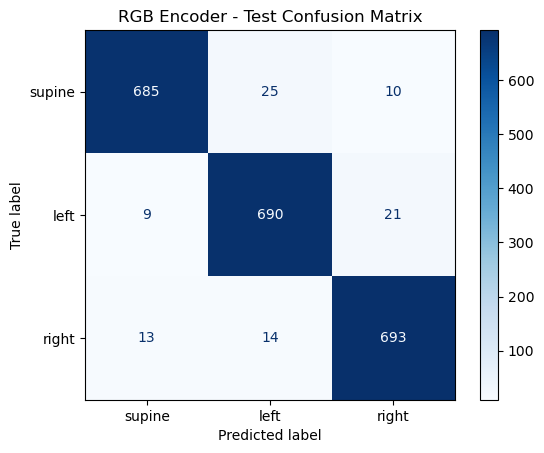

In [82]:
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Blues")
plt.title("RGB Encoder - Test Confusion Matrix")
plt.show()

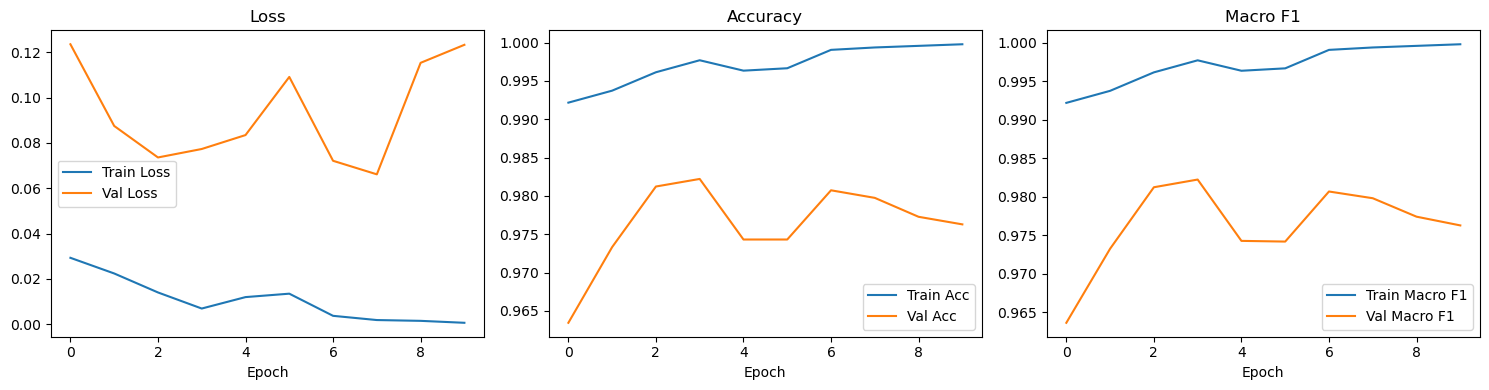

In [83]:
#plot training curve
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.title("Loss")
plt.xlabel("Epoch")
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(history["train_acc"], label="Train Acc")
plt.plot(history["val_acc"], label="Val Acc")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(history["train_macro_f1"], label="Train Macro F1")
plt.plot(history["val_macro_f1"], label="Val Macro F1")
plt.title("Macro F1")
plt.xlabel("Epoch")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
TRAIN_HISTORY_JSON_PATH = ARTIFACT_DIR / "train_history.json"

with open(TRAIN_HISTORY_JSON_PATH, "w") as f:
    json.dump(history, f, indent=4)

print(f"Saved training history to: {TRAIN_HISTORY_JSON_PATH}")

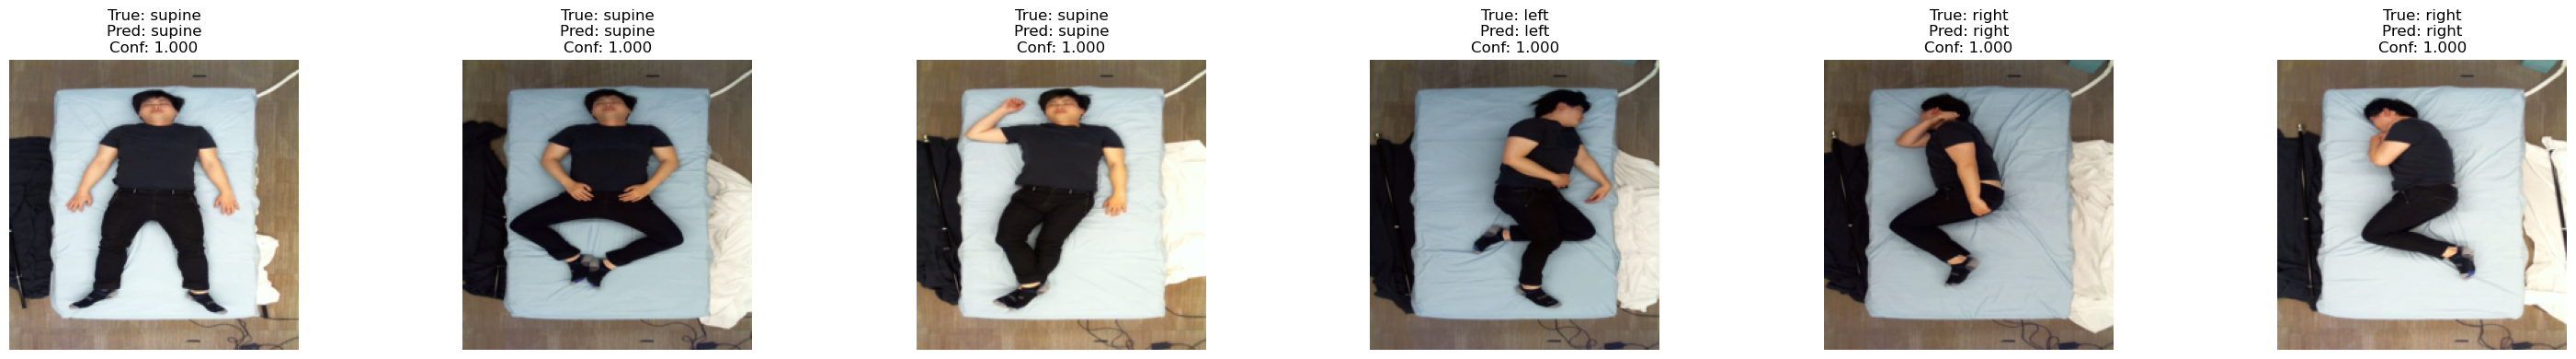

Saved example predictions to: artifacts\rgb_encoder\example_predictions.png


In [85]:
#save example predictions
example_indices = [0, 5, 10, 20, 30, 40]
save_example_predictions(
    model=model
    dataset=test_dataset,
    device=device,
    class_names=class_names,
    indices=example_indices,
    save_path=ARTIFACT_DIR / "example_predictions.png"
)

In [55]:
print("Config exists:", CONFIG_JSON_PATH.exists())
print("Checkpoint exists:", BEST_CHECKPOINT_PATH.exists())
print("Encoder exists:", BEST_ENCODER_PATH.exists())

Config exists: True
Checkpoint exists: True
Encoder exists: True


In [56]:
for p in ARTIFACT_DIR.glob("*"):
    print(p.name)

best_rgb_checkpoint.pt
best_rgb_encoder.pt
config.json
example_predictions.png
train_history.json


In [65]:
# ============================================================
# Rebuild trained model from saved checkpoint
# ============================================================


checkpoint = torch.load(
    BEST_CHECKPOINT_PATH,
    map_location=device,
    weights_only=False
)

model = RGBClassifier(
    num_classes=checkpoint["num_classes"],
    embedding_dim=checkpoint["feature_dim"],
    pretrained=False
).to(device)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

best_epoch = checkpoint["epoch"]
best_val_acc = checkpoint["best_val_acc"]
best_val_f1 = checkpoint["best_val_macro_f1"]

print("Loaded checkpoint successfully.")
print("Best epoch:", best_epoch)
print("Best val acc:", best_val_acc)
print("Best val macro F1:", best_val_f1)

Loaded checkpoint successfully.
Best epoch: 4
Best val acc: 0.9822222222222222
Best val macro F1: 0.9822111436385844


In [66]:
# ============================================================
# Evaluate on test set
# ============================================================

test_loss, test_acc, test_macro_f1 = validate_one_epoch(
    model=model,
    loader=test_loader,
    criterion=criterion,
    device=device
)

y_true, y_pred, y_probs = get_predictions_and_labels(model, test_loader, device)

print(f"Test Loss      : {test_loss:.4f}")
print(f"Test Accuracy  : {test_acc:.4f}")
print(f"Test Macro F1  : {test_macro_f1:.4f}")

Test Loss      : 0.2033
Test Accuracy  : 0.9574
Test Macro F1  : 0.9574


In [67]:
# ============================================================
# Save metrics.json
# ============================================================

metrics = {
    "best_epoch": int(best_epoch),
    "best_val_accuracy": float(best_val_acc),
    "best_val_macro_f1": float(best_val_f1),
    "test_loss": float(test_loss),
    "test_accuracy": float(test_acc),
    "test_macro_f1": float(test_macro_f1)
}

with open(METRICS_JSON_PATH, "w") as f:
    json.dump(metrics, f, indent=4)

print(f"Saved metrics to: {METRICS_JSON_PATH}")

Saved metrics to: artifacts\rgb_encoder\metrics.json


In [68]:
# ============================================================
# Save test classification report
# ============================================================

class_names = ["supine", "left", "right"]

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True
)

with open(TEST_CLASSIFICATION_REPORT_PATH, "w") as f:
    json.dump(report, f, indent=4)

print(classification_report(y_true, y_pred, target_names=class_names))
print(f"Saved classification report to: {TEST_CLASSIFICATION_REPORT_PATH}")

              precision    recall  f1-score   support

      supine       0.97      0.95      0.96       720
        left       0.95      0.96      0.95       720
       right       0.96      0.96      0.96       720

    accuracy                           0.96      2160
   macro avg       0.96      0.96      0.96      2160
weighted avg       0.96      0.96      0.96      2160

Saved classification report to: artifacts\rgb_encoder\test_classification_report.json


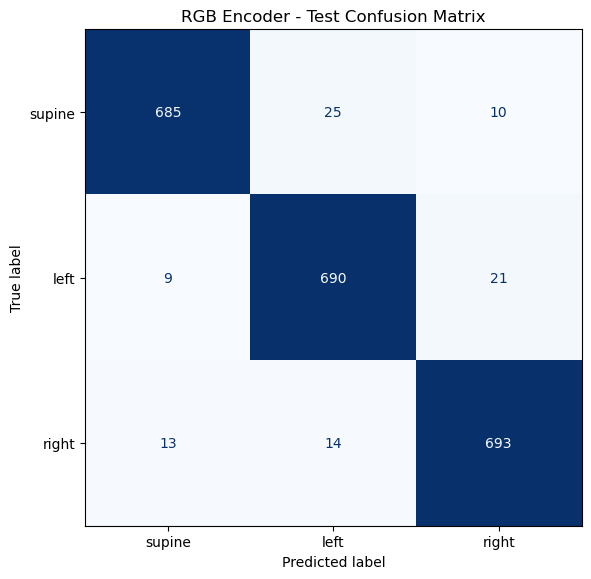

Saved confusion matrix to: artifacts\rgb_encoder\test_confusion_matrix.png


In [69]:
# ============================================================
# Save confusion matrix figure
# ============================================================

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap="Blues", ax=ax, colorbar=False)
plt.title("RGB Encoder - Test Confusion Matrix")
plt.tight_layout()
plt.savefig(TEST_CONFUSION_MATRIX_PATH, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved confusion matrix to: {TEST_CONFUSION_MATRIX_PATH}")

In [70]:
# ============================================================
# Final artifact check
# ============================================================

print("Checkpoint exists:", BEST_CHECKPOINT_PATH.exists())
print("Metrics exists:", METRICS_JSON_PATH.exists())
print("Classification report exists:", TEST_CLASSIFICATION_REPORT_PATH.exists())
print("Confusion matrix exists:", TEST_CONFUSION_MATRIX_PATH.exists())

Checkpoint exists: True
Metrics exists: True
Classification report exists: True
Confusion matrix exists: True
